<>:189: SyntaxWarning: invalid escape sequence '\d'
<>:189: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_4863/3406952514.py:189: SyntaxWarning: invalid escape sequence '\d'
  df_procesado['grupo_id'] = df_procesado[0].str.extract('(\d+)').astype(int)


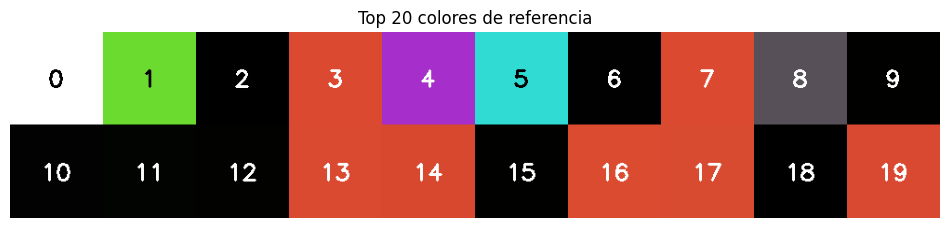

--- Guardando en: cat_1 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_2 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_3 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_4 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_5 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_6 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_7 ---
Procesada (limpia): 3a.png
Procesada (limpia): 2a.png
Procesada (limpia): 4a.png
Procesada (limpia): 5a.png
--- Guardando en: cat_8 ---
Procesada (limpia): 

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import os
import ast
import pprint
from scipy.spatial import KDTree  # Nueva dependencia para búsqueda rápida de colores

def rgb_to_hex(color):
    return "#{:02x}{:02x}{:02x}".format(int(color[0]), int(color[1]), int(color[2]))

def get_text_color(rgb):
    # Fórmula de luminancia: 0.299*R + 0.587*G + 0.114*B
    luminance = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return (255, 255, 255) if luminance < 128 else (0, 0, 0)

def get_exact_color_counts(image_path, top_n=20):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: No se pudo cargar la imagen.")
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixels = img.reshape(-1, 3)
    pixels_tuple = [tuple(p) for p in pixels]
    
    counts = Counter(pixels_tuple)
    total_pixels = len(pixels)
    sorted_counts = counts.most_common()
    
    data_list = []
    display_colors = []
    
    for i, (color, count) in enumerate(sorted_counts):
        if i >= top_n: break
        
        hex_code = rgb_to_hex(color)
        percentage = (count / total_pixels) * 100
        
        data_list.append({
            'ID': i,
            'HEX': hex_code,
            'Porcentaje': percentage,
            'RGB': color
        })
        display_colors.append({'rgb': color, 'percentage': percentage})

    df = pd.DataFrame(data_list)

    # Visualización
    rows = 2
    cols = top_n // rows
    square_size = 100
    canvas = np.ones((rows * square_size, cols * square_size, 3), dtype="uint8") * 255
    
    for i in range(top_n):
        if i >= len(display_colors): break
        r = i // cols
        c = i % cols
        color = display_colors[i]['rgb']
        x1, y1 = c * square_size, r * square_size
        x2, y2 = (c + 1) * square_size, (r + 1) * square_size
        cv2.rectangle(canvas, (x1, y1), (x2, y2), [int(x) for x in color], -1)
        txt_color = get_text_color(color)
        text = str(i)
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.8
        thickness = 2
        text_size = cv2.getTextSize(text, font, font_scale, thickness)[0]
        text_x = x1 + (square_size - text_size[0]) // 2
        text_y = y1 + (square_size + text_size[1]) // 2
        cv2.putText(canvas, text, (text_x, text_y), font, font_scale, txt_color, thickness)

    plt.figure(figsize=(12, 6))
    plt.imshow(canvas)
    plt.title(f"Top {top_n} colores de referencia")
    plt.axis("off")
    plt.show()

    return df

def hex_to_rgb(hex_code):
    hex_code = hex_code.lstrip('#')
    return tuple(int(hex_code[i:i+2], 16) for i in (0, 2, 4))

def get_next_cat_dir(base_name="cat_"):
    existing = [d for d in os.listdir('.') if os.path.isdir(d) and d.startswith(base_name)]
    indices = [int(d.split('_')[1]) for d in existing if "_" in d and d.split('_')[1].isdigit()]
    next_idx = max(indices) + 1 if indices else 1
    new_folder = f"{base_name}{next_idx}"
    os.makedirs(new_folder, exist_ok=True)
    return new_folder

def process_batch_final(or_dir, df_colores, similar_colors, replace_dict):
    output_dir = get_next_cat_dir()
    print(f"--- Guardando en: {output_dir} ---")

    # PREPARACIÓN DE LA BÚSQUEDA POR CERCANÍA
    # Extraemos los 20 colores RGB de referencia del DataFrame 
    palette_rgb = np.array(df_colores['RGB'].tolist())
    tree = KDTree(palette_rgb)

    # 1. Crear el diccionario de mapeo RGB_original -> RGB_nuevo
    mapping_rgb = {}
    for group_idx, group_list in enumerate(similar_colors):
        if group_idx in replace_dict:
            new_rgb = hex_to_rgb(replace_dict[group_idx])
            for color_id in group_list:
                row = df_colores.loc[df_colores['ID'] == color_id]
                if not row.empty:
                    ref_rgb = tuple(row['RGB'].values[0])
                    mapping_rgb[ref_rgb] = new_rgb

    for img_name in os.listdir(or_dir):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
            
        img_path = os.path.join(or_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is None: continue

        if img.shape[2] == 4:
            bgr = img[:, :, :3]
            alpha = img[:, :, 3]
        else:
            bgr = img
            alpha = None

        rgb_img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        
        # --- PASO CRÍTICO: "SNAP" AL COLOR MÁS CERCANO ---
        # Aplanamos la imagen para buscar en el árbol de colores
        h, w, c = rgb_img.shape
        pixels_flat = rgb_img.reshape(-1, 3)
        
        # Buscamos el índice del color más cercano en el palette_rgb para cada píxel
        _, indices = tree.query(pixels_flat)
        
        # Reemplazamos todos los píxeles por su "versión oficial" del Top 20
        quantized_pixels = palette_rgb[indices]
        rgb_img_quantized = quantized_pixels.reshape(h, w, c)
        
        # Ahora procedemos con el reemplazo normal sobre la imagen ya "limpia"
        new_rgb_img = rgb_img_quantized.copy()
        for orig_rgb, target_rgb in mapping_rgb.items():
            mask = np.all(rgb_img_quantized == orig_rgb, axis=-1)
            new_rgb_img[mask] = target_rgb

        final_bgr = cv2.cvtColor(new_rgb_img, cv2.COLOR_RGB2BGR)

        if alpha is not None:
            final_img = cv2.merge([final_bgr[:,:,0], final_bgr[:,:,1], final_bgr[:,:,2], alpha])
        else:
            final_img = final_bgr

        save_path = os.path.join(output_dir, os.path.splitext(img_name)[0] + ".png")
        cv2.imwrite(save_path, final_img)
        print(f"Procesada (limpia): {img_name}")

# --- Configuración y Ejecución ---

# 1. Cargar colores base
df_colores = get_exact_color_counts('./cat_base/2a.png', top_n=20)
new_colors_df = pd.read_csv("colors_new.csv", header=None)

# 2. Configuración de partes
name_to_key = {
    "Cuerpo": 0,
    "Bordes": 1,
    "Manchas": 2,
    "Ojos": 3,
    "Orejas": 4
}

# 3. Cargar nuevas paletas (Asumiendo que new_colors_df ya existe o se carga aquí)
# new_colors_df = pd.read_csv("colors_new.csv", header=None) 
# (Descomenta la línea de arriba si ejecutas el script de cero)

def rgb_str_to_hex(rgb_str):
    try:
        rgb = ast.literal_eval(rgb_str)
        return '#{:02x}{:02x}{:02x}'.format(*rgb)
    except: return rgb_str

df_procesado = new_colors_df.copy()
df_procesado['parte_nombre'] = df_procesado[0].str.extract('([a-zA-Z]+)')
df_procesado['grupo_id'] = df_procesado[0].str.extract('(\d+)').astype(int)
df_procesado['hex_color'] = df_procesado[1].apply(rgb_str_to_hex)

similar_colors = [
    [1], # Grupo 0 -> Cuerpo
    [2, 6, 9, 10, 11, 12, 15, 18], # Grupo 1 -> Bordes
    [3, 7, 13, 14, 16, 17, 19], # Grupo 2 -> Manchas
    [4], # Grupo 3 -> Ojos
    [5]  # Grupo 4 -> Orejas
]

replace_dicts = []
for _, group in df_procesado.groupby('grupo_id'):
    d = {}
    for _, row in group.iterrows():
        key = name_to_key.get(row['parte_nombre'])
        if key is not None:
            d[key] = row['hex_color']
    replace_dicts.append(d)

# 4. Ejecutar proceso
for replace_dict in replace_dicts:
    process_batch_final("./cat_base/", df_colores, similar_colors, replace_dict)